# Interpreting a screen end to end

A Cell Painting screen perturbs thousands of wells, one perturbation each, labels eight cellular
components with six fluorescent dyes imaged in five channels, and measures a few thousand morphology
features per well. Two questions follow from the
images: which perturbations *do* something, and what pathways do the active ones group into. This
page answers both on a real overexpression screen, using nothing but the mantispy interpretation
layer, and it stops at each step to teach a lesson the reproduction surfaced.

The data are the ORF arm of {cite:t}`Rohban_2017`: U2OS cells, each well overexpressing one open
reading frame (ORF). {func}`~mantispy.ds.rohban` returns the five pilot plates as well-level
augmented CellProfiler profiles, with the untreated (EMPTY) wells and the transfection controls
marked. It is a **construct-level** screen: `Metadata_Perturbation` is the ORF construct (a few
hundred of them) and `Metadata_Gene` is the gene, so several constructs can carry one gene. We keep
the construct as the unit of the active call, because reproducibility and the distance-from-control
test both need a construct's replicate wells. We then collapse the strong constructs to one signature
per gene and cluster at the **gene level**, the unit the paper reported (about 25 clusters over
roughly 220 genes, about half of them with a reproducible phenotype).

In [1]:
import warnings

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import scanpy as sc

import mantispy as mt

# Serialize plotly figures into the notebook so the interactive twins embed under nbconvert.
pio.renderers.default = "notebook_connected"
warnings.filterwarnings("ignore")
SEED = 0

adata = mt.ds.rohban()
# The paper normalized to the untreated (EMPTY) wells, not the transfection controls, so mark them.
adata.obs["is_untreated"] = (adata.obs["Metadata_Perturbation_Type"].astype(str) == "untreated").to_numpy()
screened = ~adata.obs["is_untreated"] & ~adata.obs["Metadata_Control"]
n_constructs = int(adata.obs.loc[screened, "Metadata_Perturbation"].nunique())
{
    "wells": adata.n_obs,
    "features": adata.n_vars,
    "plates": int(adata.obs["Metadata_Plate"].nunique()),
    "ORF constructs": n_constructs,
    "genes": int(adata.obs["Metadata_Gene"].astype(str).nunique()),
    "untreated (EMPTY) wells": int(adata.obs["is_untreated"].sum()),
    "transfection controls": int(adata.obs["Metadata_Control"].sum()),
}

{'wells': 1918,
 'features': 3616,
 'plates': 5,
 'ORF constructs': 323,
 'genes': 194,
 'untreated (EMPTY) wells': 175,
 'transfection controls': 120}

Five plates, a few thousand raw features, a few hundred constructs over about two hundred genes. The
untreated EMPTY wells are the negative control the whole analysis is measured against. The
transfection controls (a promiscuous ORF set the paper used for a different purpose) are neither the
baseline nor a screened construct, so they sit out of both the active call and the clustering.

## Normalize, select, reduce

Nothing downstream is trustworthy until plate-to-plate offsets are removed. We robustly normalize
each feature per plate against the untreated wells (median and MAD of the EMPTY wells set zero and
scale), drop features that are degenerate or redundant with pycytominer's defaults, and reduce to
the principal components that hold 99% of the variance. The active call runs in that PCA space.

In [2]:
mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="is_untreated")
mt.pp.feature_select(
    adata,
    operations=("drop_degenerate", "variance_threshold", "correlation_threshold", "drop_na_columns", "blocklist"),
)
adata = mt.pp.subset_features(adata)
adata.X = np.nan_to_num(np.asarray(adata.X, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)

# PCA to >=99% variance. The augmented profiles are redundant, so far fewer PCs than the paper's roughly 158.
n_try = int(min(adata.n_vars - 1, adata.n_obs - 1, 400))
sc.pp.pca(adata, n_comps=n_try, svd_solver="arpack", random_state=SEED)
cum = np.cumsum(adata.uns["pca"]["variance_ratio"])
n_pcs = min(int(np.searchsorted(cum, 0.99) + 1), n_try)
adata.obsm["X_pca"] = adata.obsm["X_pca"][:, :n_pcs].copy()
{"features kept": adata.n_vars, "PCs for >=99% variance": n_pcs, "cumulative variance": round(float(cum[n_pcs - 1]), 4)}

{'features kept': 751,
 'PCs for >=99% variance': 36,
 'cumulative variance': 0.9901}

Principal components of the wells, coloured by plate. On the raw features the plates form separate
clouds; after per-plate robust normalization against the untreated wells the plate colours are mixed.

In [3]:
# One extra PCA, on a fresh RAW copy, only for the "before" panel; deleted right after.
raw = mt.ds.rohban()
raw.X = np.nan_to_num(np.asarray(raw.X, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
sc.pp.pca(raw, n_comps=2, svd_solver="arpack", random_state=SEED)


def _z(v):
    v = np.asarray(v, dtype=np.float64)
    s = v.std()
    return (v - v.mean()) / s if s else v


def _stage(ad, label):
    """One row per well: the first two z-scored PCs, plate, construct and stage label."""
    return pd.DataFrame(
        {
            "PC1": _z(ad.obsm["X_pca"][:, 0]),
            "PC2": _z(ad.obsm["X_pca"][:, 1]),
            "plate": ad.obs["Metadata_Plate"].astype(str).to_numpy(),
            "construct": ad.obs["Metadata_Perturbation"].astype(str).to_numpy(),
            "stage": label,
        }
    )


plate_order = sorted(adata.obs["Metadata_Plate"].astype(str).unique())
before_label = "before (raw features)"
after_label = "after (per-plate robust normalization)"
batch = pd.concat([_stage(raw, before_label), _stage(adata, after_label)], ignore_index=True)
del raw

fig = px.scatter(
    batch,
    x="PC1",
    y="PC2",
    color="plate",
    facet_col="stage",
    hover_name="construct",
    category_orders={"plate": plate_order, "stage": [before_label, after_label]},
    opacity=0.6,
    title="Plate structure in the wells before and after normalization (PCA, z-scored PCs)",
)
fig.update_traces(marker={"size": 4})
fig.update_xaxes(title_text="PC1 (z-scored)")
fig.update_yaxes(title_text="PC2 (z-scored)")
fig.show()

Cumulative variance explained by the well PCA. The active call runs on the first components that
together reach 99% of the variance.

In [4]:
vr = np.asarray(adata.uns["pca"]["variance_ratio"], dtype=np.float64)
cumvar = np.cumsum(vr)
curve = pd.DataFrame({"component": np.arange(1, len(cumvar) + 1), "cumulative_variance": cumvar})
fig = px.line(
    curve,
    x="component",
    y="cumulative_variance",
    markers=True,
    title=f"Cumulative variance explained; {n_pcs} PCs reach 99%",
)
fig.add_hline(y=0.99, line_dash="dot", annotation_text="0.99")
fig.add_vline(x=n_pcs, line_dash="dash", annotation_text=f"n_pcs = {n_pcs}")
fig.update_xaxes(title_text="principal component")
fig.update_yaxes(title_text="cumulative variance ratio")
fig.show()

## The active call is two stages, and both matter

Which constructs *do* something? A screen needs two numbers, not one, and confusing them overcounts
the hits.

1. **Reproducible.** Do a construct's replicate wells look more like each other than like unrelated
   wells? {func}`~mantispy.tl.percent_replicating` compares each construct's median replicate
   correlation against a non-replicate null and keeps the constructs above the 95th percentile of
   that null.
2. **Distinct from the negative control.** Does the construct actually sit away from the untreated
   baseline? {func}`~mantispy.tl.hit_calling` measures the Mahalanobis distance of each construct
   from the untreated wells and calibrates it with a permutation null.

These are different questions. A construct can be perfectly reproducible and still sit on top of the
control (a reproducible non-phenotype, for example a construct that does nothing but does it
consistently), and a construct can be far from the control on a single noisy well that does not
replicate. The **strong** set is the intersection: reproducible *and* moved. The paper selected hits
this way and clustered only the strong subset, so we do too.

Two details carry the reproduction. `hit_calling` here reads the raw `pvalue`, not the BH `qvalue`:
the paper's stage 2 keeps constructs past the 95th percentile of the control-to-control distance,
which is an uncorrected per-construct p < 0.05, not an FDR cut. And `covariance="empirical"` is
required: the robust (minimum-covariance-determinant) fit inflates the distance of stray control
wells, fattening the null's tail until the calls collapse to almost nothing. We keep
`n_permutations` small here so the page runs quickly; the strong set is stable well below the
benchmark's 500.

In [5]:
# The screened constructs (drop the untreated baseline and the transfection controls).
screen = adata[(~adata.obs["is_untreated"] & ~adata.obs["Metadata_Control"]).to_numpy()].copy()

# Stage 1: replicate reproducibility against a 95th-percentile non-replicate null.
mt.tl.percent_replicating(
    screen, groupby="Metadata_Perturbation", metric="pearson", quantile=0.95, use_rep="X_pca", seed=SEED
)
pr = screen.uns["mantispy"]["percent_replicating"]
replicating = set(pr.loc[pr["is_replicating"], "group"].astype(str))

# Stage 2: Mahalanobis distance from the untreated control. hit_calling needs the controls in the
# object as its reference, so run it on the constructs plus the untreated wells.
hits_adata = adata[(~adata.obs["Metadata_Control"]).to_numpy()].copy()
mt.tl.hit_calling(
    hits_adata,
    groupby="Metadata_Perturbation",
    reference="is_untreated",
    method="mahalanobis",
    covariance="empirical",
    use_rep="X_pca",
    n_permutations=200,
    threshold=0.05,
    seed=SEED,
)
hits = hits_adata.uns["mantispy"]["hits"]
# Uncorrected p<0.05 matches the paper's 95th-percentile distance-to-control cut (its stage 2 is not FDR corrected).
hit = set(hits.loc[hits["pvalue"] < 0.05, "group"].astype(str)) - {"untreated"}

strong = replicating & hit
{
    "stage 1 reproducible": len(replicating),
    "stage 2 moved from control": len(hit),
    "STRONG (both)": len(strong),
    "strong fraction": round(len(strong) / n_constructs, 3),
}

{'stage 1 reproducible': 243,
 'stage 2 moved from control': 133,
 'STRONG (both)': 100,
 'strong fraction': 0.31}

Stage 1 as mantispy draws it. {func}`~mantispy.pl.replicate_correlation` places every construct's median replicate correlation against its own non-replicate null threshold; the constructs above the diagonal clear the 95th-percentile cut and make up the reproducible set. Stage 2 is a distance, so it enters the combined view below rather than a plot of its own.

In [6]:
# Stage 1 as its own diagnostic: reproducibility against each construct's non-replicate null.
_ = mt.pl.replicate_correlation(screen, key="percent_replicating")

Each screened construct placed by its replicate reproducibility (x) and its distance from the
untreated control (y). The two axes are independent; the strong set is the intersection in the upper
right, and either axis alone admits constructs the other rejects.

In [7]:
pr_tab = pr[["group", "median_replicate_correlation", "is_replicating", "null_threshold"]].copy()
pr_tab["group"] = pr_tab["group"].astype(str)
hits_tab = hits[["group", "distance", "pvalue"]].copy()
hits_tab["group"] = hits_tab["group"].astype(str)
hits_tab = hits_tab[hits_tab["group"] != "untreated"]

call = pr_tab.merge(hits_tab, on="group", how="inner")
call["moved"] = call["pvalue"] < 0.05


def _label(row):
    if row["is_replicating"] and row["moved"]:
        return "STRONG (both)"
    if row["is_replicating"]:
        return "reproducible only"
    if row["moved"]:
        return "moved only"
    return "neither"


call["set"] = call.apply(_label, axis=1)
repro_cut = float(pr_tab["null_threshold"].median())
dist_cut = float(call.loc[call["moved"], "distance"].min())

color_map = {
    "STRONG (both)": "#d62728",
    "reproducible only": "#1f77b4",
    "moved only": "#ff7f0e",
    "neither": "#b0b0b0",
}
fig = px.scatter(
    call,
    x="median_replicate_correlation",
    y="distance",
    color="set",
    hover_name="group",
    color_discrete_map=color_map,
    category_orders={"set": ["STRONG (both)", "reproducible only", "moved only", "neither"]},
    opacity=0.75,
    title="The two-stage active call: reproducible (x) against moved from control (y)",
)
fig.update_traces(marker={"size": 6})
fig.add_vline(x=repro_cut, line_dash="dash", annotation_text="reproducibility cut (median null)")
fig.add_hline(y=dist_cut, line_dash="dash", annotation_text="distance cut (p<0.05)")
fig.update_xaxes(title_text="median replicate correlation")
fig.update_yaxes(title_text="Mahalanobis distance from control")
fig.show()

## Collapse the strong constructs to one signature per gene

Rohban clusters at the **gene level**: one profile per gene, and the reported clusters (about 25 of
them) are groups of genes. Our active call, though, runs on constructs, because
{func}`~mantispy.tl.percent_replicating` and {func}`~mantispy.tl.hit_calling` both need a construct's
replicate wells. To cluster at the paper's unit we bridge the two: pool the wells of every strong
construct and take one {func}`~mantispy.tl.consensus` per gene, so a gene with at least one strong
construct contributes a single gene-level signature.

`modz` collapses a gene's wells into a weighted mean that downweights wells disagreeing with the rest,
which suits noisy replicates. We also keep a per-**construct** consensus over the whole screen; the
network step at the end uses it.

In [8]:
# Per-construct consensus over the whole screen (the network step at the end uses this map).
cons = mt.tl.consensus(screen, by="Metadata_Perturbation", method="modz", correlation="spearman", min_replicates=2)
cons.X = np.nan_to_num(np.asarray(cons.X, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)

# Collapse the strong constructs to one signature per gene: pool every strong construct's wells and
# take a modz consensus per gene, so each gene with a strong construct becomes one gene-level profile.
strong_wells = screen[screen.obs["Metadata_Perturbation"].astype(str).isin(strong)].copy()
cons_gene = mt.tl.consensus(strong_wells, by="Metadata_Gene", method="modz", correlation="spearman", min_replicates=2)
cons_gene.X = np.nan_to_num(np.asarray(cons_gene.X, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
{"all constructs": cons.n_obs, "strong constructs": len(strong), "genes clustered": cons_gene.n_obs}

{'all constructs': 323, 'strong constructs': 100, 'genes clustered': 77}

## Clustering: cut in the high-correlation band, on the strong genes

A correlation-distance tree over a whole screen is top-heavy. Most perturbations correlate only
weakly with each other, so they form one large, shallow blob that merges near the top of the
dendrogram, and a handful of tight modules hang below it. Two things follow.

First, cut the tree where the structure is, not where a global score is flattest. An unbounded
stability or silhouette sweep is pulled toward the shallow top of the tree and collapses the whole
screen into two or three clusters. {func}`~mantispy.tl.cluster` with `criterion="stability"` and a
`stability_window` restricted to the high-correlation band finds the cut inside the range where real
modules live. For `metric="correlation"` a dendrogram height is `1 - correlation`, so the window
`(0.3, 0.6)` in height is the correlation window 0.4 to 0.7 the paper swept.

Second, feed the clustering a clean unit. The strong gene signatures are the concentrated end of the
screen: strong constructs, collapsed to genes. Clustering the raw construct map instead, all 323
constructs at once, lets the weakly-correlated noise dominate. The cell below shows it: the same
stability cut shatters the construct map into more than fifty clusters and splits the Hippo pair, with
YAP1 and WWTR1 landing apart. Collapsing to the strong genes, the paper's unit, is what sharpens the
modules.

In [9]:
# Demonstrate the over-segmentation: cluster ALL constructs with the identical settings.
cons_all = cons.copy()
mt.tl.cluster(
    cons_all,
    use_rep=None,
    method="hierarchical",
    linkage="average",
    metric="correlation",
    criterion="stability",
    stability_window=(0.3, 0.6),
)
lab_all = cons_all.obs["cluster"].astype(str)
gene_all = cons_all.obs["Metadata_Gene"].astype(str)
yap_all = set(lab_all[gene_all == "YAP1"])
taz_all = set(lab_all[gene_all == "WWTR1"])
{
    "all constructs clustered": cons_all.n_obs,
    "clusters with >=2 constructs": int((lab_all.value_counts() >= 2).sum()),
    "YAP1 and WWTR1 in the same cluster": bool(yap_all & taz_all),
}

{'all constructs clustered': 323,
 'clusters with >=2 constructs': 56,
 'YAP1 and WWTR1 in the same cluster': False}

In [10]:
mt.tl.cluster(
    cons_gene,
    use_rep=None,
    method="hierarchical",
    linkage="average",
    metric="correlation",
    criterion="stability",
    stability_window=(0.3, 0.6),
)
mt.tl.similarity(cons_gene, metric="pearson", use_rep=None)

lab = cons_gene.obs["cluster"].astype(str)
gene = cons_gene.obs["Metadata_Gene"].astype(str)
sizes = lab.value_counts()
multigene = set(sizes[sizes >= 2].index)
{
    "stability cut (height)": round(float(cons_gene.uns["mantispy"]["cluster"]["distance_cut"]), 3),
    "total clusters": int(lab.nunique()),
    "clusters with >=2 genes": int((sizes >= 2).sum()),
}

{'stability cut (height)': 0.458,
 'total clusters': 31,
 'clusters with >=2 genes': 15}

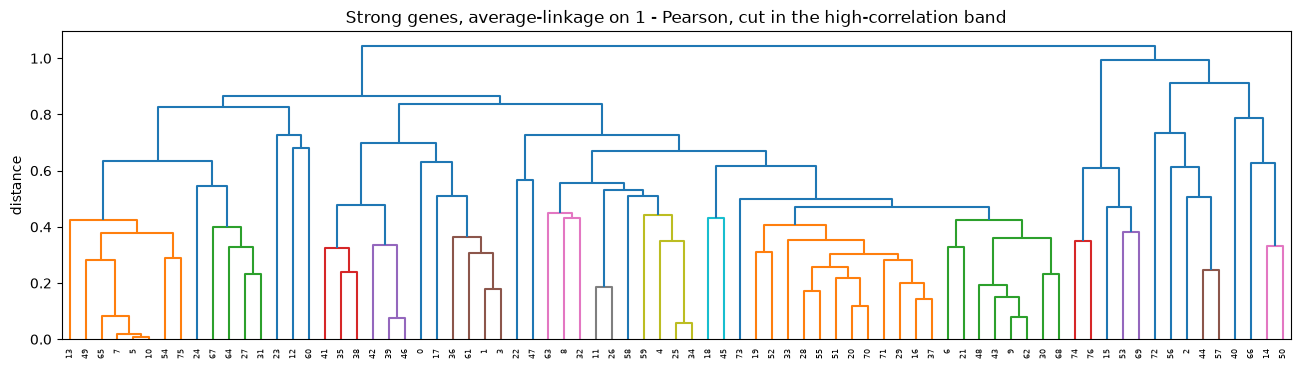

In [11]:
import matplotlib.pyplot as plt

ax = mt.pl.dendrogram(cons_gene, key="cluster", color_threshold=cons_gene.uns["mantispy"]["cluster"]["distance_cut"])
ax.set_title("Strong genes, average-linkage on 1 - Pearson, cut in the high-correlation band")
plt.show()

Thirty-one clusters, fifteen of them holding two or more genes, cut at a height around 0.46 (a Pearson
correlation of about 0.54). The paper reported about 25 clusters over roughly 220 gene signatures. We
now cluster the paper's unit, one signature per gene, so the comparison is like for like, but the
counts do not match exactly: 31 against the paper's ~25, with our clusters smaller (two to twelve
genes) than theirs. Matching the unit is what keeps the count in that range: clustering all 323
constructs instead over-segments the screen into 56 multi-construct clusters (the cell above), far
more than either the gene view or the paper, and it splits tight pairs like Hippo. The residual gap
from 31 down toward the paper's ~25 is input size and cut placement, not the unit: 77 strong genes
here against the paper's roughly 220, from lower-rank pilot profiles, cut slightly finer. What
matching the unit buys is that the modules and the enrichment below are now directly comparable to the
paper's gene-level results, not that the count agrees.

In [12]:
S = np.asarray(cons_gene.obsp["similarity"], dtype=np.float64)
pos = {name: i for i, name in enumerate(cons_gene.obs_names)}
lab_by_name = lab.to_dict()
name_of_gene = {gene.iloc[i]: cons_gene.obs_names[i] for i in range(cons_gene.n_obs)}


def cluster_of(g: str) -> str | None:
    """Cluster label of gene g's single gene-level signature, or None if g has no strong construct."""
    name = name_of_gene.get(g)
    return lab_by_name.get(name) if name is not None else None


def members(cluster: str) -> list[int]:
    """Row positions of the genes in a cluster."""
    return [pos[name] for name in cons_gene.obs_names if lab_by_name[name] == cluster]


def mean_between(a: list[int], b: list[int]) -> float:
    """Mean pairwise Pearson similarity between two groups of genes."""
    return float(np.mean(S[np.ix_(a, b)])) if a and b else float("nan")


present = set(gene)

# 1. Hippo: YAP1 and WWTR1 (TAZ) are single points now; do they land in the same cluster?
yap_cluster = cluster_of("YAP1")
taz_cluster = cluster_of("WWTR1")
hippo_same = yap_cluster is not None and yap_cluster == taz_cluster

# 2. RAS-RAF-MEK-ERK: which clusters hold two or more cascade genes?
RAS = {"KRAS", "HRAS", "NRAS", "BRAF", "RAF1", "MAP2K1", "MAP2K3", "MAP2K4", "MAPK1", "MAPK3", "SOS1"}
cascade_by_cluster: dict[str, set[str]] = {}
for g in sorted(g for g in RAS if g in present):
    cascade_by_cluster.setdefault(cluster_of(g), set()).add(g)
ras_modules = {c: sorted(gs) for c, gs in cascade_by_cluster.items() if len(gs) >= 2}

# 3. NF-kB against YAP: the paper reports the NF-kB module anti-correlating with the Hippo/YAP module.
nfkb = []
for g in ["TRAF2", "RELA", "NFKB1", "REL", "CHUK", "IKBKB"]:
    c = cluster_of(g)
    if c is not None and c != yap_cluster:
        nfkb.append({"gene": g, "r_vs_YAP": round(mean_between(members(yap_cluster), members(c)), 3)})

{
    "YAP1 cluster": yap_cluster,
    "WWTR1 cluster": taz_cluster,
    "YAP1 and WWTR1 together": hippo_same,
    "RAS cascade co-clusters": ras_modules,
    "NF-kB vs YAP cluster mean Pearson": nfkb,
}

{'YAP1 cluster': '22',
 'WWTR1 cluster': '22',
 'YAP1 and WWTR1 together': True,
 'RAS cascade co-clusters': {'20': ['BRAF', 'RAF1'], '7': ['HRAS', 'KRAS']},
 'NF-kB vs YAP cluster mean Pearson': [{'gene': 'RELA', 'r_vs_YAP': 0.015},
  {'gene': 'NFKB1', 'r_vs_YAP': -0.086},
  {'gene': 'REL', 'r_vs_YAP': -0.444}]}

At the gene level the anchor modules recover cleanly from morphology alone:

- **Hippo.** YAP1 and WWTR1 (TAZ), the two Hippo pathway co-activators, are single gene-level points
  now, and they fall in the **same cluster**. Overexpressing either drives the same transcriptional
  program, and the cells look alike.
- **RAS-RAF-MEK-ERK.** The canonical growth-factor cascade resolves into two separate modules: a
  RAS/MAPK cluster that holds the RAF kinases BRAF and RAF1 alongside several more cascade genes (the
  ORA below counts five of its genes in the MAPK-cascade term), and a distinct cluster for the RAS
  GTPases HRAS and KRAS. One route, split along its GTPase and kinase tiers, each tier morphologically
  coherent.
- **NF-kB against YAP (partial).** The paper reports the NF-kB module anti-correlating with the
  Hippo/YAP module. The REL proto-oncogene sits clearly opposite the YAP cluster (mean Pearson about
  -0.44), while RELA and NFKB1 sit near zero. The opposition is carried by REL rather than by every
  NF-kB gene, so it is real but thinner than the paper's gene-level module.

Pearson similarity between the strong gene signatures, rows and columns ordered by cluster. The
diagonal blocks are the modules, including the Hippo block (YAP1, WWTR1) and the RAS/MAPK block
(BRAF, RAF1, HRAS, KRAS).

In [13]:
# The strong-gene Pearson map, rows and columns ordered by cluster so the modules sit on the diagonal.
# Name the rows by gene so the interactive map labels each profile; mt.pl.similarity reads obsp["similarity"].
cons_gene.obs_names = cons_gene.obs["Metadata_Gene"].astype(str)
_ = mt.pl.similarity(cons_gene, key="similarity", groupby="cluster")

## Over-representation: naming the clusters, and testing the names

The clusters look like pathways. Can we name them automatically? {func}`~mantispy.tl.ora` asks, per
cluster, whether the cluster's genes are over-represented in an annotated gene set with a Fisher exact
test, and here the cluster members are genes directly (`gene_key="Metadata_Gene"`). The sequence below
is the one the reproduction taught: the naive correction finds almost nothing, the paper's looser
recipe finds nearly everything, and only a null separates the paper's trustworthy hits from the rest.

In [14]:
def build_net(specs):
    """Concatenate ds.gene_sets collections, prefixing each set id with its source."""
    parts = []
    for name, prefix in specs:
        part = mt.ds.gene_sets(name)[["source", "target"]].copy()
        part["source"] = f"{prefix}:" + part["source"].astype(str)
        parts.append(part)
    return pd.concat(parts, ignore_index=True)


broad = build_net([("GO_BP", "GO"), ("CORUM", "CORUM"), ("Reactome", "REACTOME")])

# Naive: the broad GO-BP + CORUM + Reactome collection, per-cluster BH.
mt.tl.ora(
    cons_gene,
    groupby="cluster",
    net=broad,
    gene_key="Metadata_Gene",
    tmin=5,
    padj_by="group",
    min_overlap=1,
    key_added="ora",
)
naive = cons_gene.uns["mantispy"]["ora"]
family = naive.groupby("group", observed=True).size().reindex(list(multigene)).dropna()
{
    "sets tested per multi-gene cluster (median)": int(family.median()),
    f"multi-gene clusters at q<0.05 (of {len(multigene)})": len(
        set(naive.loc[naive["qvalue"] < 0.05, "group"].astype(str)) & multigene
    ),
    f"multi-gene clusters at nominal p<0.05 (of {len(multigene)})": len(
        set(naive.loc[naive["pvalue"] < 0.05, "group"].astype(str)) & multigene
    ),
}

{'sets tested per multi-gene cluster (median)': 276,
 'multi-gene clusters at q<0.05 (of 15)': 1,
 'multi-gene clusters at nominal p<0.05 (of 15)': 15}

BH over a broad collection has almost no power here. Conventional ORA (`min_overlap=1`) already drops
the sets none of a cluster's genes touch, so each small cluster is still corrected over the few hundred
sets its two-to-twelve genes hit. Even so, just **one** of the fifteen multi-gene clusters clears
q < 0.05, though all fifteen of them carry a nominal enrichment. A handful of genes tested against a
collection of thousands cannot survive honest FDR: the signal is real but too thin for BH at this
scale.

### The paper's recipe

Rohban did not run BH over a broad collection. They tested **GO biological process only**, took the
universe to be the clustered genes themselves, required at least two of a cluster's genes in a set
(their `Significant >= 2`), and read the **nominal** Fisher p-value, no multiple-testing correction.
That is exactly {func}`~mantispy.tl.ora` on the gene-level object (its universe is `obs[gene_key]`,
here the clustered genes) with `net` restricted to GO-BP, `min_overlap=2`, and the `pvalue` column.

In [15]:
gobp = mt.ds.gene_sets("GO_BP")[["source", "target"]].copy()

# The paper's recipe: GO-BP only, universe = the clustered genes, >=2 genes per set, nominal p (no correction).
mt.tl.ora(
    cons_gene,
    groupby="cluster",
    net=gobp,
    gene_key="Metadata_Gene",
    tmin=5,
    min_overlap=2,
    key_added="ora_gobp",
)
gobp_ora = cons_gene.uns["mantispy"]["ora_gobp"]


def enriched_their_way(ora: pd.DataFrame, universe: set[str]) -> set[str]:
    """Clusters with at least one over-represented GO-BP term at nominal p < 0.05."""
    hit = ora[(ora["pvalue"] < 0.05) & (ora["odds_ratio"] > 0)]
    return set(hit["group"].astype(str)) & universe


def term(cluster: str, source: str) -> str | None:
    """Format one GO-BP term's result for one cluster, or None if the term was not tested there."""
    row = gobp_ora[(gobp_ora["group"].astype(str) == cluster) & (gobp_ora["source"].astype(str) == source)]
    if row.empty:
        return None
    r = row.iloc[0]
    return f"p={r['pvalue']:.3f}, genes={int(r['n'])}, log-odds={r['odds_ratio']:.2f}"


enriched = enriched_their_way(gobp_ora, multigene)
ras_cluster = cluster_of("BRAF")
{
    f"clusters enriched the paper's way (of {len(multigene)})": len(enriched),
    "YAP1/WWTR1 cluster: GOBP_HIPPO_SIGNALING": term(yap_cluster, "GOBP_HIPPO_SIGNALING"),
    "RAS cluster: GOBP_POSITIVE_REGULATION_OF_ERK1_AND_ERK2_CASCADE": term(
        ras_cluster, "GOBP_POSITIVE_REGULATION_OF_ERK1_AND_ERK2_CASCADE"
    ),
    "RAS cluster: GOBP_POSITIVE_REGULATION_OF_MAPK_CASCADE": term(
        ras_cluster, "GOBP_POSITIVE_REGULATION_OF_MAPK_CASCADE"
    ),
}

{"clusters enriched the paper's way (of 15)": 15,
 'YAP1/WWTR1 cluster: GOBP_HIPPO_SIGNALING': 'p=0.005, genes=2, log-odds=4.38',
 'RAS cluster: GOBP_POSITIVE_REGULATION_OF_ERK1_AND_ERK2_CASCADE': 'p=0.012, genes=4, log-odds=2.12',
 'RAS cluster: GOBP_POSITIVE_REGULATION_OF_MAPK_CASCADE': 'p=0.031, genes=5, log-odds=1.63'}

Enriched almost everywhere. **Fifteen of the fifteen** multi-gene clusters carry a nominal GO-BP term,
an even higher rate than the paper's roughly 19 of 22. And the anchors land where the biology says they
should: **GOBP_HIPPO_SIGNALING** is over-represented on the exact cluster that holds YAP1 and WWTR1
(both of its two Hippo genes, p about 0.005), and the **ERK1/2 and MAPK cascade** regulation terms are
enriched on the RAS/MAPK cluster that holds BRAF and RAF1 among five or more genes (p about 0.01 to 0.03;
the giant generic `GOBP_MAPK_CASCADE` set is too large to reach significance on its own). Naming the
clusters this way recovers the paper's modules.

A 100% hit rate is itself a warning. Nominal p with `min_overlap=2` over thousands of GO-BP sets will
flag a term for almost any small group of genes. Shuffling the labels shows how much of that count is
signal.

In [16]:
rng = np.random.default_rng(SEED)
null_counts = []
for _ in range(30):
    shuffled = cons_gene.copy()
    shuffled.obs["cluster"] = cons_gene.obs["cluster"].to_numpy()[rng.permutation(shuffled.n_obs)]
    mt.tl.ora(
        shuffled,
        groupby="cluster",
        net=gobp,
        gene_key="Metadata_Gene",
        tmin=5,
        min_overlap=2,
        key_added="ora_gobp",
    )
    g = shuffled.obs["Metadata_Gene"].astype(str)
    mg = set(g.groupby(shuffled.obs["cluster"].astype(str), observed=True).nunique().pipe(lambda s: s[s >= 2].index))
    null_counts.append(len(enriched_their_way(shuffled.uns["mantispy"]["ora_gobp"], mg)))

null_counts = np.asarray(null_counts)
{
    "observed clusters enriched the paper's way": len(enriched),
    "null mean": round(float(null_counts.mean()), 2),
    "null max": int(null_counts.max()),
    "empirical p (null >= observed)": round(float((null_counts >= len(enriched)).mean()), 3),
}

{"observed clusters enriched the paper's way": 15,
 'null mean': 12.7,
 'null max': 15,
 'empirical p (null >= observed)': 0.033}

Distribution of the enriched-cluster count across 30 label shuffles, with the observed count
marked. On shuffled labels the same nominal recipe enriches nearly as many clusters, so the count
alone carries little information; terms are trustworthy when they are both biologically coherent and
stand apart from this null.

In [17]:
observed = int(len(enriched))
emp_p = float((null_counts >= observed).mean())
fig = px.histogram(
    x=null_counts,
    nbins=int(null_counts.max() - null_counts.min() + 1),
    title="Clusters enriched on shuffled labels (null) against the observed count",
)
fig.add_vline(
    x=observed,
    line_dash="dash",
    line_color="#d62728",
    annotation_text=f"observed = {observed} (empirical p = {emp_p:.3f})",
)
fig.update_xaxes(title_text="multi-gene clusters enriched at nominal p<0.05")
fig.update_yaxes(title_text="shuffles")
fig.show()

The null enriches too. On shuffled gene-to-cluster labels the same nominal recipe enriches about
**thirteen** clusters on average (up to fifteen), against fifteen observed. The observed count sits
barely above the null bulk, so the *number* of enriched clusters carries almost no information: with
two-gene overlaps and nominal p, nearly every small cluster looks enriched whether or not its genes
belong together.

Running the null makes the point:

- Nominal ORA at this granularity is **exploratory, not FDR-controlled**. Do not report a count of
  enriched clusters, or a list of surviving terms, as if the null were silent. Here it is not.
- Trust a term when it is **biologically coherent** with the cluster's known genes **and stands out
  from the null**. GOBP_HIPPO_SIGNALING on the YAP1/WWTR1 cluster and the ERK/MAPK terms on the RAF
  cluster qualify on both counts: they name the pathway the anchor genes are known to drive, and they
  attach to the right cluster rather than a random one. A GO term about renal-tubule development on the
  same cluster does not.
- The durable pathway signal in this screen lives at the clustering and network level (the Hippo and
  RAS modules, the partial NF-kB opposition, and the interaction enrichment below), which carry their
  own much stronger nulls, not in per-cluster ORA counts. A fuller sweep of the correction methods
  reaches the same conclusion: the test universe and a null check are the levers, not the estimator.

Clustering the paper's gene unit recovers the paper's gene-level modules: Hippo
(YAP1/WWTR1) and MAPK (the RAS-RAF cascade), each named by the right GO-BP term. The count differences
from the paper (31 clusters against about 25, and every testable cluster nominally enriched against
their roughly 19 of 22) trace to method choices, the gene-versus-construct unit and the paper's lack of
FDR, not to a failure to reproduce. Always pair an enrichment with a null.

## Interaction enrichment of the top-correlated pairs

One more line of evidence, independent of the clustering. If the map is biologically structured, the
construct pairs that correlate most strongly should be enriched for known physical interactions.
{func}`~mantispy.tl.network_enrichment` takes the top 5% most similar pairs and asks whether they
share a CORUM complex more often than the rest.

In [18]:
mt.tl.similarity(cons, metric="pearson", use_rep=None)
edges = mt.ds.interactions("CORUM")
mt.tl.network_enrichment(cons, similarity_key="similarity", edges=edges, gene_key="Metadata_Gene", top_quantile=0.95)
ne = cons.uns["mantispy"]["network_enrichment"]
(a11, a10), (a01, a00) = ne["table"]
{
    "correlation cut (top 5%)": round(float(ne["threshold"]), 3),
    "top pairs sharing a CORUM complex": f"{a11}/{a11 + a10} = {100 * a11 / max(a11 + a10, 1):.1f}%",
    "other pairs sharing a CORUM complex": f"{100 * a01 / max(a01 + a00, 1):.1f}%",
    "odds ratio": round(float(ne["odds_ratio"]), 2),
    "one-sided Fisher p": float(ne["pvalue"]),
}

{'correlation cut (top 5%)': 0.549,
 'top pairs sharing a CORUM complex': '52/2601 = 2.0%',
 'other pairs sharing a CORUM complex': '0.9%',
 'odds ratio': 2.13,
 'one-sided Fisher p': 2.0427118341541552e-06}

Rate at which construct pairs share a CORUM complex, for the top 5% most similar pairs against the
rest.

In [19]:
(n11, n10), (n01, n00) = ne["table"]
rates = pd.DataFrame(
    {
        "pairs": ["top 5% most similar", "all other pairs"],
        "corum_rate": [100 * n11 / max(n11 + n10, 1), 100 * n01 / max(n01 + n00, 1)],
    }
)
fig = px.bar(
    rates,
    x="pairs",
    y="corum_rate",
    color="pairs",
    color_discrete_sequence=["#d62728", "#b0b0b0"],
    title=f"CORUM co-membership rate (odds ratio {ne['odds_ratio']:.2f}, p = {ne['pvalue']:.1e})",
)
fig.update_xaxes(title_text="")
fig.update_yaxes(title_text="pairs sharing a CORUM complex (%)")
fig.update_layout(showlegend=False)
fig.show()

The most-correlated construct pairs are about twice as likely to share a CORUM complex as the rest,
with a comfortably significant p-value over thousands of pairs. Unlike the per-cluster ORA, this test
pools all pairs into one comparison with a large, well-behaved null, so it corroborates the
clustering biology directly. (The absolute rates are low because CORUM co-membership is a sparse
proxy for the paper's physical-interaction reference, but the direction and significance hold.)

## The recipe, and three lessons

The whole pipeline, reusable on any construct- or perturbation-level screen:

> **load** (`ds.rohban`) then **normalize + select + PCA** (`pp.normalize`, `pp.feature_select`,
> `sc.pp.pca`) then **strong call** (`tl.percent_replicating` AND `tl.hit_calling`) then
> **collapse strong constructs to one signature per gene** (`tl.consensus`) then
> **cluster the genes** (`tl.cluster`) then **enrich** (`tl.ora`) then
> **network** (`tl.network_enrichment`).

And the three lessons the reproduction taught, each one a place it is easy to go wrong:

1. **The active call is two stages.** Reproducible is not the same as phenotypic. Keep the constructs
   that both replicate and move away from the control; either stage alone overcounts.
2. **Cluster the paper's unit, and cut in the high-correlation band.** A screen's tree is top-heavy,
   so an unbounded cut collapses it and feeding in the raw construct noise over-segments and splits
   tight pairs like Hippo. Collapse the strong constructs to one signature per gene and bound the
   stability sweep to where the modules are.
3. **For enrichment, the test universe and a null check matter more than the correction method.**
   Correcting per cluster over a broad collection buries real signal, and a fancier estimator does not
   fix a denominator full of hypotheses you never tested; restricting to GO-BP with a stronger overlap
   filter, the paper's recipe, surfaces the modules. Then shuffle the labels and look: at gene
   granularity the null is not quiet, so read the per-cluster hits as suggestive labels, and trust the
   clustering- and network-level evidence, which carry much stronger nulls.